In [48]:
import sys
from pathlib import Path

_root = next(p for p in Path.cwd().resolve().parents if (p / '.git').exists() or (p / 'setup.py').exists())
for _p in (str(_root), str(_root / 'src')):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from metab_processing.metab_travlr_config import DATA_DIR
from metab_processing.SpaceTravLR.dataset_configs import dataset_paths
from metab_processing.LinearRegression.build_x import get_gene_factors

In [49]:
# dataset = '12362_HS7_ICI-Slice_4'
# dataset = '12362_HS7_ICI-Slice_3'

dataset = '13473_HS4_UC-Slice_1'

# dataset = '13117_HS2_HC-Slice_2'

# dataset = '13557_HS3_HC-Slice_2'

In [50]:
# paths = dataset_paths('Primary_Dermal_Melanoma', data_dir=f'{DATA_DIR}/Xenium')
ADATA_PATH = f'{DATA_DIR}/Alexi_UC_Spliced/{dataset}/LinearRegression/hvgall_x_adata.h5ad'
adata = sc.read_h5ad(ADATA_PATH)
# ANNOT_COL = 'Tier1'
ANNOT_COL, CELL_TYPE = '25_06_11_ICI_5K_Coarse_annotations', 'IEC'
print(adata.n_obs, 'cells |', len(adata.uns['x_genes']), 'genes')

12142 cells | 4736 genes


In [51]:
def build_matrix(gene, metabs=None, annot_col=None, annot_value=None, zscore=True):
    """Factor matrix (cells x factors) for `gene`. `metabs`: None (default, no metabolites)
    / 'all' / a list. Optional cell filter: `annot_col` == `annot_value` (a value or a list);
    default all cells. zscore=True -> each column mean 0, std 1 (drops constant columns);
    zscore=False -> raw factor values (zeros intact, for dropout)."""
    X = get_gene_factors(adata, gene, metabs=metabs)
    if annot_col is not None:
        vals = [annot_value] if isinstance(annot_value, str) else list(annot_value)
        X = X.loc[adata.obs[annot_col].astype(str).isin([str(v) for v in vals]).values]
    if not zscore:
        return X
    X = X.loc[:, X.std() > 0]
    return (X - X.mean()) / X.std()

In [52]:
def cluster_factors(Z, threshold=0.5, method='average'):
    """Hierarchical clustering of the factors. Distance = 1 - correlation, where the
    correlation of the z-scored columns IS their covariance (~ normalized dot product).
    Returns ({group_id: [factors]}, linkage)."""
    corr = np.corrcoef(Z.values.T)
    dist = 1 - corr
    np.fill_diagonal(dist, 0)
    L = linkage(squareform(dist, checks=False), method=method)
    labels = fcluster(L, t=threshold, criterion='distance')
    groups = {}
    for f, lab in zip(Z.columns, labels):
        groups.setdefault(int(lab), []).append(f)
    return groups, L

In [53]:
GENE = 'DUOX2' # adata.uns['x_genes'][0]     # <- select the target gene
Z = build_matrix(GENE, metabs=None, annot_col=ANNOT_COL, annot_value='IEC')
groups, L = cluster_factors(Z, threshold=.5)
print(f'{GENE}: {Z.shape[1]} factors -> {len(groups)} groups')
for g, m in sorted(groups.items()):
    print(f'group {g} ({len(m)}): {m}')

DUOX2: 725 factors -> 596 groups
group 1 (1): ['CLEC2A$KLRB1']
group 2 (1): ['THY1$ITGB3']
group 3 (2): ['CD40LG$ITGB3', 'ANGPTL4$ITGB3']
group 4 (2): ['TNXB$ITGB3', 'THBS1$ITGB3']
group 5 (2): ['IGF1$ITGB3', 'TNC$ITGB3']
group 6 (2): ['ANGPTL3$ITGB3', 'POSTN$ITGB3']
group 7 (1): ['IGF2$ITGB3']
group 8 (1): ['JAM3$ITGB2']
group 9 (1): ['FGF23#PAX5']
group 10 (1): ['PAX5']
group 11 (2): ['FCER2$ITGAM', 'ICAM1$ITGAM']
group 12 (3): ['CD40LG$ITGAM', 'CD40LG$ITGB2', 'THY1$ITGAM']
group 13 (1): ['THY1$ITGB2']
group 14 (3): ['CD226$PVR', 'ITGB2$CD226', 'PVR$CD226']
group 15 (1): ['TNF$TNFRSF1A']
group 16 (1): ['IL16$CD4']
group 17 (1): ['HLA-DRA$CD4']
group 18 (1): ['HLA-DRB1$CD4']
group 19 (1): ['F11R$ITGB2']
group 20 (1): ['LCK$CD8A']
group 21 (1): ['LCK$CD8B']
group 22 (1): ['IL20$IL22RA1']
group 23 (1): ['IL22$IL22RA1']
group 24 (2): ['F11R$JAM2', 'JAM2$F11R']
group 25 (1): ['JAM2$JAM2']
group 26 (1): ['F2$F2RL1']
group 27 (1): ['ICAM2$ITGAM']
group 28 (2): ['IL34$CSF1R', 'CSF1$CSF1R']
g

In [54]:
groups

{480: ['CTCF', 'IL26#CTCF'],
 69: ['CTCFL', 'JAG1#CTCFL'],
 484: ['E2F4', 'IL26#E2F4'],
 51: ['EGR2', 'IL15#EGR2'],
 335: ['ELK4', 'IL26#ELK4'],
 222: ['ETS1', 'EGF#ETS1'],
 345: ['HDAC2', 'IL26#HDAC2'],
 547: ['HNF4A', 'IGF1#HNF4A'],
 373: ['HSF1', 'IL26#HSF1'],
 473: ['IRF1'],
 591: ['KLF5'],
 124: ['MEF2A', 'IL26#MEF2A'],
 60: ['MEF2C'],
 73: ['MSC', 'TGFB1#MSC'],
 191: ['NFATC1'],
 137: ['NFATC2', 'ANGPTL4#NFATC2'],
 421: ['NFATC3'],
 86: ['NFATC4'],
 201: ['NFKB1', 'IFNG#NFKB1'],
 253: ['NHLH2', 'IL26#NHLH2', 'IL22#NHLH2'],
 490: ['NR1H3', 'CSF1#NR1H3', 'PDGFA#NR1H3'],
 530: ['NR1H4', 'TGFB1#NR1H4'],
 398: ['NR3C1'],
 197: ['NRF1', 'CNTF#NRF1'],
 10: ['PAX5'],
 327: ['PAX6'],
 544: ['POLR2A', 'IL18#POLR2A', 'TGFA#POLR2A'],
 97: ['POU2F2'],
 404: ['PRDM1', 'IL21#PRDM1'],
 549: ['RREB1', 'IL18#RREB1', 'ADM#RREB1'],
 527: ['RXRA', 'IL26#RXRA'],
 340: ['SMC3', 'IL26#SMC3'],
 426: ['SP1', 'EGF#SP1'],
 193: ['STAT1'],
 476: ['STAT2'],
 313: ['STAT3', 'IL12A#STAT3'],
 74: ['TAF1'],
 425:

In [55]:
def pca_group(group, Z=None, n=None):
    """PCA on one group's factors. `group`: a group id from `groups`, a list of factor
    names, or a DataFrame. Plots the explained-variance scree + a PC x factor loadings
    heatmap. Returns the fitted PCA."""
    Z = globals()['Z'] if Z is None else Z
    cols = groups[group] if isinstance(group, int) else (
        list(group.columns) if isinstance(group, pd.DataFrame) else list(group))
    p = PCA(n_components=n).fit(Z[cols].values)
    plt.plot(np.arange(1, p.n_components_ + 1), p.explained_variance_ratio_, 'o-')
    plt.xlabel('PC'); plt.ylabel('explained var'); plt.show()
    load = pd.DataFrame(p.components_, columns=cols,
                        index=[f'PC{i+1}' for i in range(p.n_components_)])
    v = np.abs(load.values).max()
    plt.figure(figsize=(min(1 + 0.3 * len(cols), 20), 1 + 0.3 * len(load)))
    plt.imshow(load, aspect='auto', cmap='RdBu_r', vmin=-v, vmax=v); plt.colorbar()
    plt.yticks(range(len(load)), load.index); plt.xticks(range(len(cols)), cols, rotation=90)
    plt.tight_layout(); plt.show()
    return p

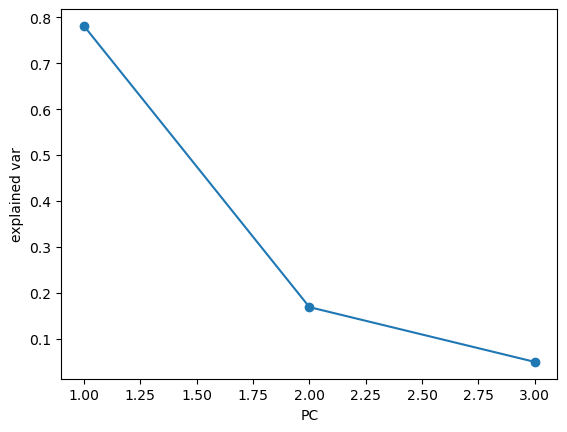

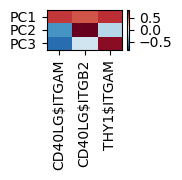

In [56]:
p = pca_group(sorted(groups)[11])   # a group id, or pass a list of factors / a DataFrame

In [57]:
def _sides(c):
    """The matchable name parts of a factor: [lig, rec] for `lig$rec`, [lig, tf] for
    `lig#tf`, the metabolite name for `metab@name`, else the bare TF name."""
    for sep in ('$', '#', '@'):
        if sep in c:
            return c.split(sep)
    return [c]

def select(query, X, exact_match=False):
    """Sub-df of X's factor columns. `query`: a substring (default) or a list of exact names.
    exact_match=True -> keep a factor only if `query` is the WHOLE bare-TF/metabolite name,
    or an exact match of one side of a `$` (L-R) or `#` (L-TF) factor."""
    if not isinstance(query, str):
        cols = list(query)
    elif exact_match:
        cols = [c for c in X.columns if query in _sides(c)]
    else:
        cols = [c for c in X.columns if query in c]
    print(f'{len(cols)} factors:', cols)
    return X[cols]

def plot_corr(X):
    """Correlation heatmap between X's factor columns."""
    c = X.corr(); n = len(c); s = min(1 + 0.4 * n, 18)
    plt.figure(figsize=(s, s))
    plt.imshow(c, cmap='RdBu_r', vmin=-1, vmax=1); plt.colorbar()
    plt.xticks(range(n), c.columns, rotation=90); plt.yticks(range(n), c.index)
    plt.tight_layout(); plt.show()

def plot_dropout(X):
    """Per factor: dropout = fraction of cells where the factor == 0 (its local RNA is
    absent -- receptor for lig$rec, TF for lig#tf, the gene for a bare TF), and the mean
    value. Pass a RAW (un-z-scored) sub-df. Also prints both in scientific notation, since
    the factor groups sit on very different scales (which flattens the linear bars)."""
    drop = (X == 0).mean()
    mean = X.mean()
    print(pd.DataFrame({'dropout': drop, 'mean': mean}).to_string(float_format='{:.3e}'.format))
    fig, ax = plt.subplots(1, 2, figsize=(min(1 + 0.5 * X.shape[1], 22), 4))
    drop.plot.bar(ax=ax[0], title='dropout (frac == 0)')
    mean.plot.bar(ax=ax[1], title='mean value')
    plt.tight_layout(); plt.show()

def plot_pair(f1, f2, annot_value=None, metabs='all'):
    """Scatter two factors' ORIGINAL-scale (raw) values against each other for the current
    GENE, optional cell-type subset via `annot_value`; draws the best-fit line and annotates
    Pearson r and r^2."""
    X = build_matrix(GENE, metabs=metabs,
                     annot_col=ANNOT_COL if annot_value is not None else None,
                     annot_value=annot_value, zscore=False)
    x, y = X[f1].values, X[f2].values
    r = np.corrcoef(x, y)[0, 1]
    m, b = np.polyfit(x, y, 1)
    plt.scatter(x, y, s=5, alpha=0.3)
    xs = np.array([x.min(), x.max()]); plt.plot(xs, m * xs + b, 'r-')
    plt.xlabel(f1); plt.ylabel(f2); plt.title(f'r = {r:.3f}   r^2 = {r ** 2:.3f}')
    plt.show()

In [58]:
# raw (un-z-scored) factor matrix for the same gene/cells -- zeros intact, for dropout
Xraw = build_matrix(GENE, metabs=None, annot_col=ANNOT_COL, annot_value='IEC', zscore=False)

7 factors: ['CD40LG$ITGAM', 'FCER2$ITGAM', 'GP1BA$ITGAM', 'ICAM1$ITGAM', 'ICAM2$ITGAM', 'JAM3$ITGAM', 'THY1$ITGAM']


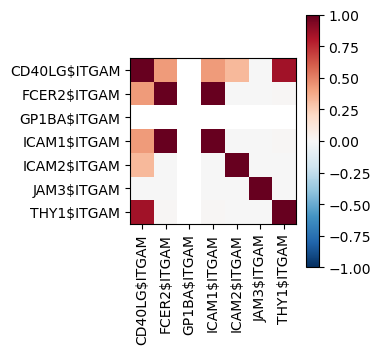

               dropout      mean
CD40LG$ITGAM 9.991e-01 1.511e-08
FCER2$ITGAM  9.999e-01 1.230e-11
GP1BA$ITGAM  1.000e+00 0.000e+00
ICAM1$ITGAM  9.999e-01 1.230e-11
ICAM2$ITGAM  9.999e-01 1.359e-10
JAM3$ITGAM   9.999e-01 5.162e-12
THY1$ITGAM   9.995e-01 1.538e-09


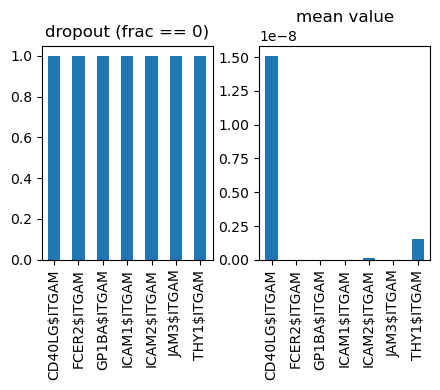

In [59]:
NAME = 'ITGAM'              # <- a receptor or TF (substring); or pass a list to select()
sub = select(NAME, Xraw)     # sub-df -- filter/slice however you like and reuse the plots below
plot_corr(sub)
plot_dropout(sub)

In [60]:
# original-scale scatter of two factors (best-fit line + r / r^2); subset by cell type.
cols = sub.columns
if len(cols) >= 2:
    plot_pair(cols[0], cols[1], annot_value='T Cell')

/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


TypeError: expected non-empty vector for x